In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("D:/EDA/eda/rawdata/NewMergedNearMiss_3.1.csv")

In [3]:
data

,NME ID,Ref.No.,Name of Ship,Type of Ship,Date of Report,Delay (in days),Description of the incident and cause analysis,Location,Probability of Reoccurence,Cause Analysis,...,IndirectCause,RootCause,RevisedIncidentCategory,LessionLearnt,ReviewComments,ClosingNote,ClosingDate,Incident_Category_Potential,Probability_of_Reoccurence,Port Country Name
0,NME100000,CAL-01/2012,APL CALIFORNIA,CONTAINER,2012-01-03,0.0,On 03 Jan 2012 @ 0254 hrs vessel berthed at qi...,Galley,Likely,Suspect undeclared machinery stowed inside a c...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Marginal-Moderate-Medium,Likely-High-Medium-Moderate,NaN
1,NME100001,CHI-01/2012,TS CHINA,CONTAINER,2012-01-05,0.0,"The ship departed port of osaka ,and main engi...",Machinery Room,Very Low,Failure to follow repair / maintenance instruc...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Critical-Severe,Very Unlikely-Very Low,NaN
2,NME100002,CHI-02/2012,TS CHINA,CONTAINER,2012-01-06,0.0,While the Ship was in Port ( NAGOYA - JAPAN ) ...,Machinery Room,Very Low,Failure to follow repair/maintenance instructi...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Marginal-Moderate-Medium,Very Unlikely-Very Low,NaN
3,NME100003,FLD-01-2012,APL FLORIDA,CONTAINER,2012-01-09,2.0,"Vessel approaching berth at Yokohama,Japan wit...",Bridge,Very Low,"Prior arrival to Yokohama, vessel had very bad...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Minor-Low-Slight,Very Unlikely-Very Low,NaN
4,NME100004,CAP-001/12,CALA PINGUINO,CONTAINER,2012-01-23,16.0,AFT TUG LINE PARTED WHILE DEPARTING PUERTO CAB...,Mooring Area,Very Likely,Duty Officer should always check the quality o...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Minor-Low-Slight,Very Likely-Very High,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12441,NME112441,NM/NBAL/2020/Apr/4,NORD BALTIC,NAN,2020-04-12 17:43:37.050,NaN,Stevedores about to transfer shore escavator u...,Sea,Likely,NaN,...,NaN,NaN,NaN,NaN,NaN,Thank you for being vigilant and devoting time...,2020-04-29 00:00:00,Marginal-Moderate-Medium,Likely-High-Medium-Moderate,NaN
12442,NME112442,NM/NSFX/2020/Apr/6,NAVIOS FELIX,NAN,2020-04-21 06:22:51.907,NaN,"During Safety around checked, 4/E was focussin...",Sea,Unlikely,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Catastrophic-Major-Extreme,Unlikely-Low-Marginal,NaN
12443,NME112443,NM/VOLN/2020/Apr/7,VOLANTE,NAN,2020-04-30 12:20:24.683,NaN,During routine round of the engine room it was...,Sea,Likely,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Minor-Low-Slight,Likely-High-Medium-Moderate,NaN
12444,NME112444,NM/HOUM/2020/Apr/8,HOURAI MARU,NAN,2020-04-24 13:43:40.970,NaN,While casting off the tug at aft station the t...,Port,Unlikely,NaN,...,NaN,NaN,NaN,NaN,NaN,UNSAFE CONDITION.NM Closed,2020-05-11 00:00:00,Minor-Low-Slight,Unlikely-Low-Marginal,NaN


In [4]:
data.describe()

,Delay (in days),Time Period (in days),year
count,1251.000000,338.000000,5858.000000
mean,4.031175,-6237.183432,2015.790031
std,1662.269228,14931.322805,2.732379
min,-41501.000000,-41698.000000,2010.000000
25%,0.000000,2.000000,2014.000000
50%,1.000000,21.000000,2016.000000
75%,3.000000,57.250000,2018.000000
max,41610.000000,195.000000,2019.000000


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12446 entries, 0 to 12445
Data columns (total 58 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   NME ID                                          12446 non-null  str    
 1   Ref.No.                                         12445 non-null  str    
 2   Name of Ship                                    12446 non-null  str    
 3   Type of Ship                                    12446 non-null  str    
 4   Date of Report                                  11787 non-null  str    
 5   Delay (in days)                                 1251 non-null   float64
 6   Description of the incident and cause analysis  12344 non-null  str    
 7   Location                                        11773 non-null  str    
 8   Probability of Reoccurence                      11583 non-null  str    
 9   Cause Analysis                                  49

In [6]:
data.columns

Index(['NME ID', 'Ref.No.', 'Name of Ship', 'Type of Ship', 'Date of Report',
       'Delay (in days)', 'Description of the incident and cause analysis',
       'Location', 'Probability of Reoccurence', 'Cause Analysis',
       'Counter measure to prevent recurrence',
       'Suggested Corrective Action (Office Use)',
       'Date Corrective action completed', 'Area of Concern',
       'Date Investigation Commenced', 'Target Date',
       'Date of Investigation Completion', 'Extension (if any) with remarks',
       'Time Period (in days)', 'Status', 'Master', 'Chief Engineer',
       'Superintendent', 'Details of potential loss Category',
       'Date of Near Miss', 'year', 'PIC', 'Port Name', 'Related Department',
       'Description of event leading to the incident',
       'Immediate action taken', 'Potential extent of damage/injury',
       'Potential Damage category', 'Potential Damage subcategory',
       'Immediate action initiated', 'Learning Potential',
       'Severity of inc

In [7]:
# convert to lowercase
data.columns = data.columns.str.lower()

# remove leading/trailing spaces
data.columns = data.columns.str.strip()

# replace spaces with underscore
data.columns = data.columns.str.replace(' ', '_')

# remove special characters like '.', '-', etc.
data.columns = data.columns.str.replace(r'[^\w\s]', '', regex=True)

# final clean (again replace spaces after removing special chars)
data.columns = data.columns.str.replace(' ', '_')

print(data.columns)

Index(['nme_id', 'refno', 'name_of_ship', 'type_of_ship', 'date_of_report',
       'delay_in_days', 'description_of_the_incident_and_cause_analysis',
       'location', 'probability_of_reoccurence', 'cause_analysis',
       'counter_measure_to_prevent_recurrence',
       'suggested_corrective_action_office_use',
       'date_corrective_action_completed', 'area_of_concern',
       'date_investigation_commenced', 'target_date',
       'date_of_investigation_completion', 'extension_if_any_with_remarks',
       'time_period_in_days', 'status', 'master', 'chief_engineer',
       'superintendent', 'details_of_potential_loss_category',
       'date_of_near_miss', 'year', 'pic', 'port_name', 'related_department',
       'description_of_event_leading_to_the_incident',
       'immediate_action_taken', 'potential_extent_of_damageinjury',
       'potential_damage_category', 'potential_damage_subcategory',
       'immediate_action_initiated', 'learning_potential',
       'severity_of_incident', 'ex

In [8]:
data = data.rename(columns={
    'name_of_ship': 'ship_name',
    'type_of_ship': 'ship_type',
    'date_of_report': 'report_date',
    'delay_in_days': 'delay_days',
    'description_of_the_incident_and_cause_analysis': 'incident_desc',
    'probability_of_reoccurence': 'prob_reoccurrence',
    'counter_measure_to_prevent_recurrence': 'countermeasure',
    'suggested_corrective_action_office_use': 'suggested_ca',
    'date_corrective_action_completed': 'ca_completed_date',
    'area_of_concern': 'area',
    'date_investigation_commenced': 'investigation_start',
    'date_of_investigation_completion': 'investigation_end',
    'time_period_in_days': 'time_period',
    'details_of_potential_loss_category': 'loss_category',
    'date_of_near_miss': 'near_miss_date',
    'port_name': 'port',
    'port_country_name': 'country'
})

In [9]:
data.isnull().sum()


data['delay_days'] = data['delay_days'].fillna(data['delay_days'].median())

data = data.fillna('Unknown')

In [10]:
date_cols = ['report_date', 'ca_completed_date', 'investigation_start',
             'investigation_end', 'near_miss_date', 'closingdate']

for col in date_cols:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

data['delay_days'] = pd.to_numeric(data['delay_days'], errors='coerce')

C:\Users\user\AppData\Local\Temp\ipykernel_21488\2018202670.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col] = pd.to_datetime(data[col], errors='coerce')
C:\Users\user\AppData\Local\Temp\ipykernel_21488\2018202670.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col] = pd.to_datetime(data[col], errors='coerce')


In [11]:
data = data.drop_duplicates()

In [12]:
text_cols = ['ship_type', 'status', 'country', 'area']

for col in text_cols:
    if col in data.columns:
        data[col] = data[col].str.lower().str.strip()

In [13]:
data['report_year'] = data['report_date'].dt.year
data['report_month'] = data['report_date'].dt.month

data['investigation_duration'] = (data['investigation_end'] - data['investigation_start']).dt.days

In [14]:
data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 12446 entries, 0 to 12445
Data columns (total 61 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   nme_id                                         12446 non-null  str           
 1   refno                                          12446 non-null  str           
 2   ship_name                                      12446 non-null  str           
 3   ship_type                                      12446 non-null  str           
 4   report_date                                    1271 non-null   datetime64[us]
 5   delay_days                                     12446 non-null  float64       
 6   incident_desc                                  12446 non-null  str           
 7   location                                       12446 non-null  str           
 8   prob_reoccurrence                              12446 non-null  str 

,nme_id,refno,ship_name,ship_type,report_date,delay_days,incident_desc,location,prob_reoccurrence,cause_analysis,...,lessionlearnt,reviewcomments,closingnote,closingdate,incident_category_potential,prob_reoccurrence,country,report_year,report_month,investigation_duration
0,NME100000,CAL-01/2012,APL CALIFORNIA,container,2012-01-03,0.0,On 03 Jan 2012 @ 0254 hrs vessel berthed at qi...,Galley,Likely,Suspect undeclared machinery stowed inside a c...,...,Unknown,Unknown,Unknown,NaT,Marginal-Moderate-Medium,Likely-High-Medium-Moderate,unknown,2012.0,1.0,146.0
1,NME100001,CHI-01/2012,TS CHINA,container,2012-01-05,0.0,"The ship departed port of osaka ,and main engi...",Machinery Room,Very Low,Failure to follow repair / maintenance instruc...,...,Unknown,Unknown,Unknown,NaT,Critical-Severe,Very Unlikely-Very Low,unknown,2012.0,1.0,64.0
2,NME100002,CHI-02/2012,TS CHINA,container,2012-01-06,0.0,While the Ship was in Port ( NAGOYA - JAPAN ) ...,Machinery Room,Very Low,Failure to follow repair/maintenance instructi...,...,Unknown,Unknown,Unknown,NaT,Marginal-Moderate-Medium,Very Unlikely-Very Low,unknown,2012.0,1.0,64.0
3,NME100003,FLD-01-2012,APL FLORIDA,container,2012-01-09,2.0,"Vessel approaching berth at Yokohama,Japan wit...",Bridge,Very Low,"Prior arrival to Yokohama, vessel had very bad...",...,Unknown,Unknown,Unknown,NaT,Minor-Low-Slight,Very Unlikely-Very Low,unknown,2012.0,1.0,NaN
4,NME100004,CAP-001/12,CALA PINGUINO,container,2012-01-23,16.0,AFT TUG LINE PARTED WHILE DEPARTING PUERTO CAB...,Mooring Area,Very Likely,Duty Officer should always check the quality o...,...,Unknown,Unknown,Unknown,NaT,Minor-Low-Slight,Very Likely-Very High,unknown,2012.0,1.0,NaN


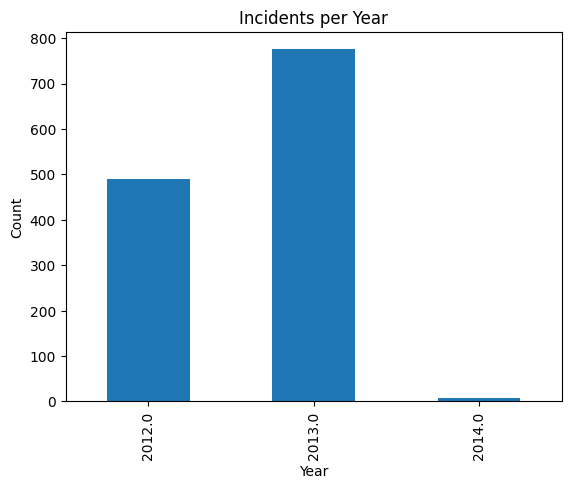

In [15]:
import matplotlib.pyplot as plt

data['report_year'].value_counts().sort_index().plot(kind='bar')
plt.title("Incidents per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

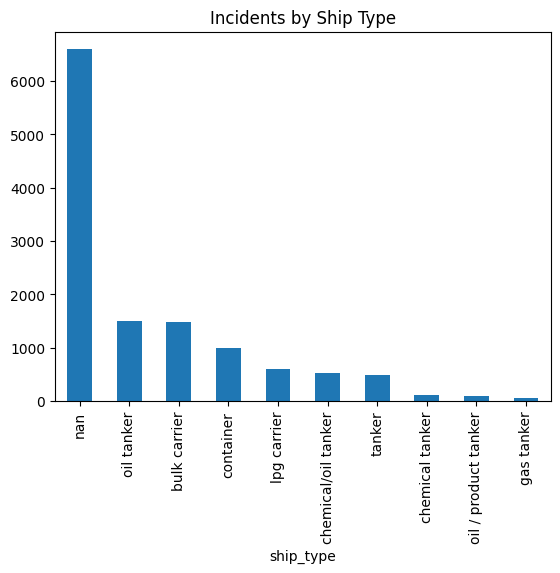

In [16]:
data['ship_type'].value_counts().head(10).plot(kind='bar')
plt.title("Incidents by Ship Type")
plt.show()

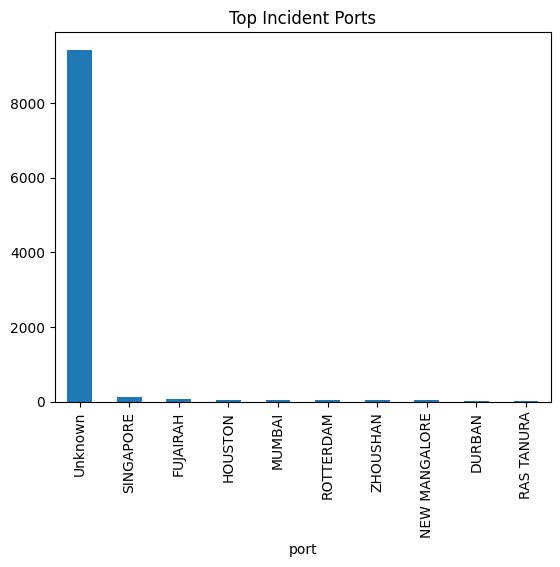

In [17]:
data['port'].value_counts().head(10).plot(kind='bar')
plt.title("Top Incident Ports")
plt.show()

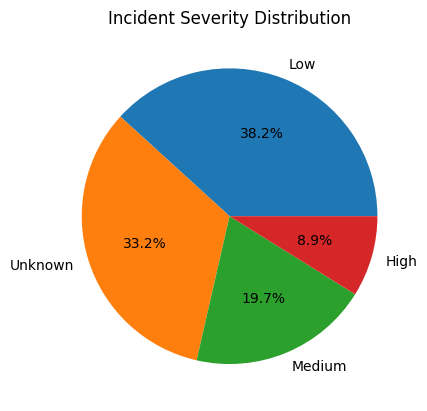

In [18]:
data['severity_of_incident'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Incident Severity Distribution")
plt.show()

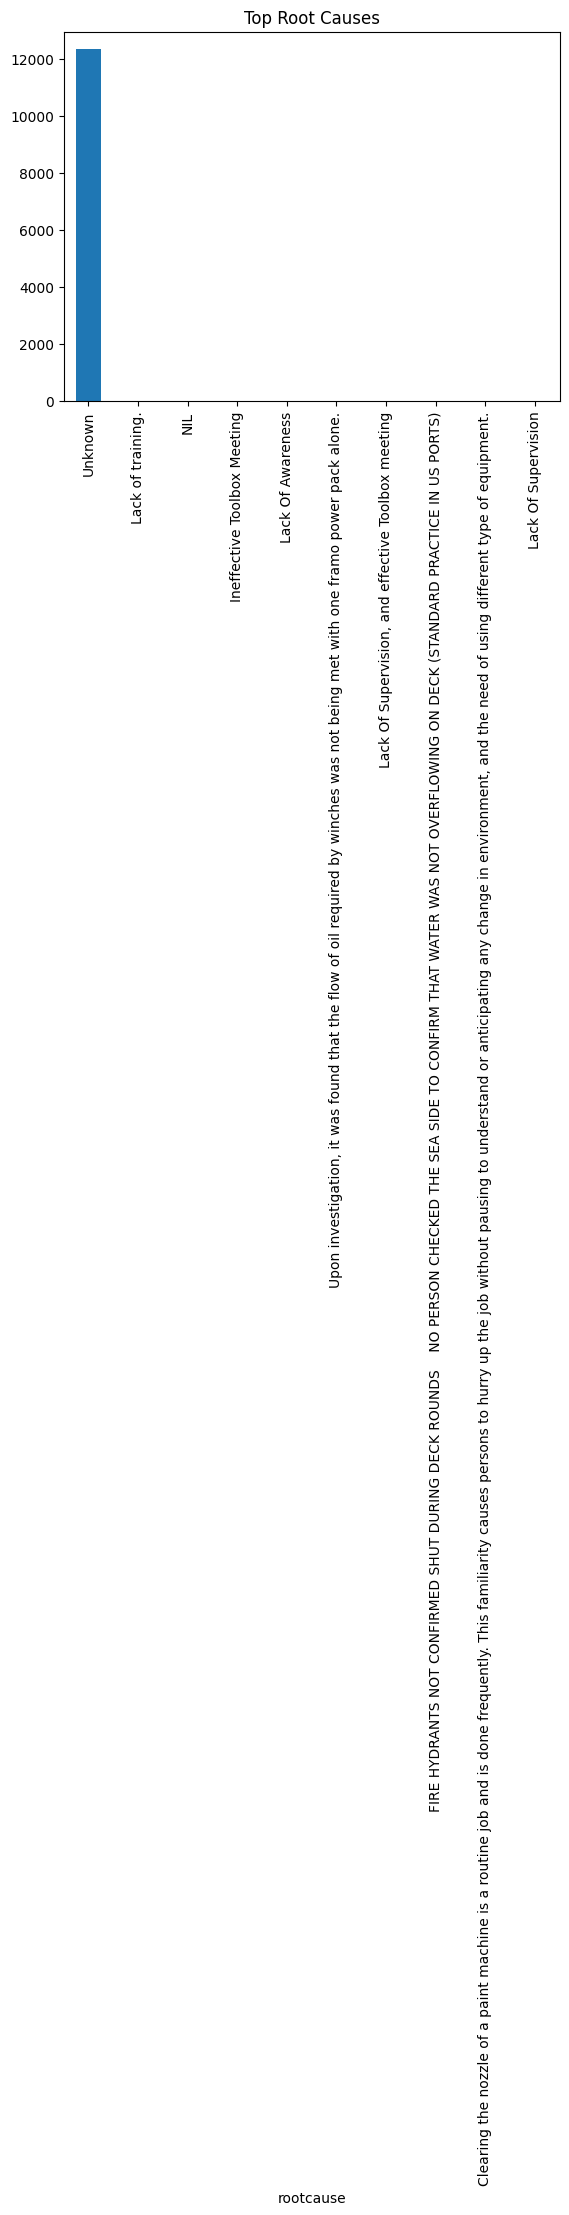

In [19]:
data['rootcause'].value_counts().head(10).plot(kind='bar')
plt.title("Top Root Causes")
plt.show()

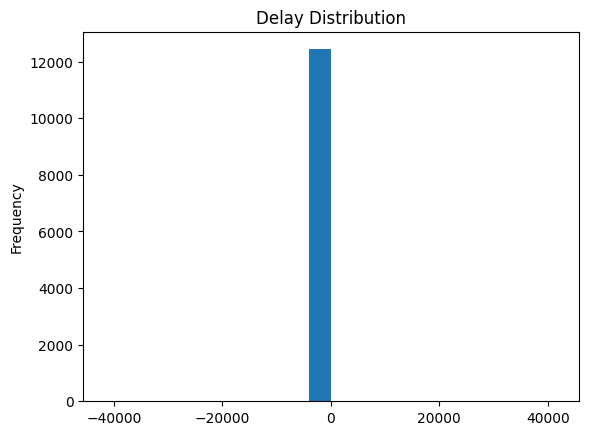

In [20]:
data['delay_days'].plot(kind='hist', bins=20)
plt.title("Delay Distribution")
plt.show()

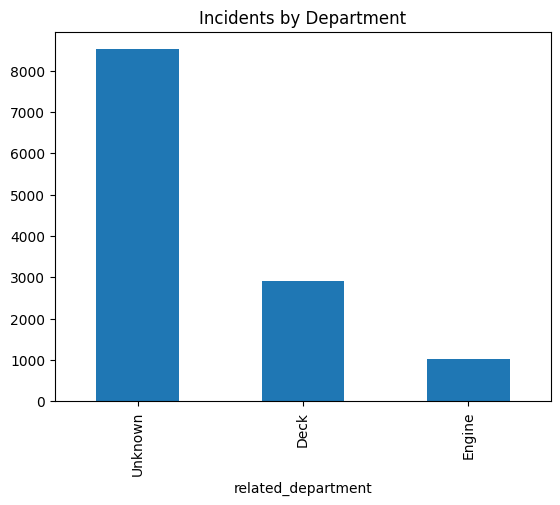

In [21]:
data['related_department'].value_counts().plot(kind='bar')
plt.title("Incidents by Department")
plt.show()

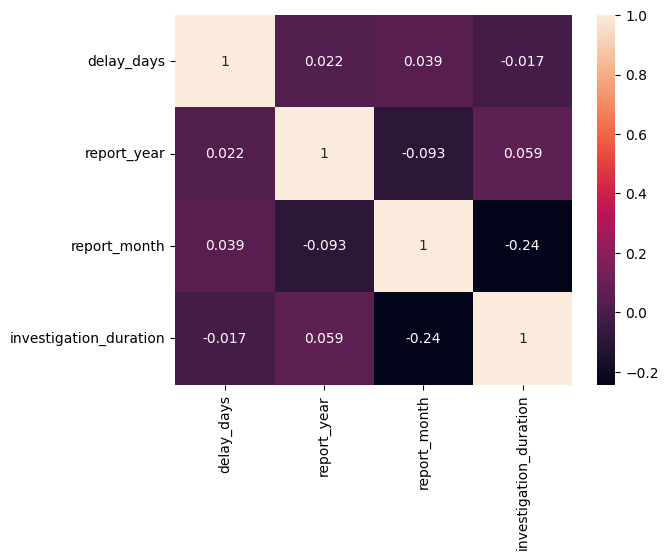

In [22]:
import seaborn as sns

sns.heatmap(data.corr(numeric_only=True), annot=True)

plt.show()

In [23]:
data.groupby(['ship_type', 'port']).size().sort_values(ascending=False).head(10)

ship_type             port     
nan                   Unknown      4630
bulk carrier          Unknown      1254
oil tanker            Unknown      1122
container             Unknown       803
tanker                Unknown       489
lpg carrier           Unknown       459
chemical/oil tanker   Unknown       407
chemical tanker       Unknown       108
oil / product tanker  Unknown        98
nan                   SINGAPORE      80
dtype: int64

In [24]:
data['investigation_duration'].describe()

count     858.000000
mean       40.278555
std        75.914313
min      -273.000000
25%         6.000000
50%        22.000000
75%        52.000000
max      1495.000000
Name: investigation_duration, dtype: float64

In [26]:
data = data[data['investigation_duration'] >= 0]

In [27]:
data = data[data['investigation_duration'] <= 365]  # keep within 1 year

In [28]:
Q1 = data['investigation_duration'].quantile(0.25)
Q3 = data['investigation_duration'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['investigation_duration'] >= lower_bound) & 
            (data['investigation_duration'] <= upper_bound)]

In [29]:
data['investigation_duration'].describe()

count    764.000000
mean      27.848168
std       27.334451
min        0.000000
25%        6.000000
50%       19.000000
75%       43.000000
max      119.000000
Name: investigation_duration, dtype: float64

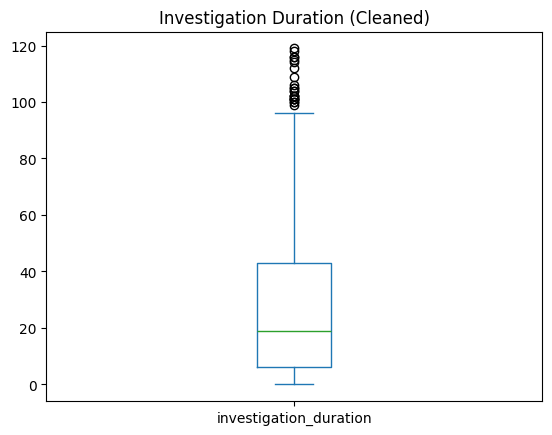

In [30]:
import matplotlib.pyplot as plt

data['investigation_duration'].plot(kind='box')
plt.title("Investigation Duration (Cleaned)")
plt.show()

In [31]:
data.shape
data.info()
data.describe()

<class 'pandas.DataFrame'>
Index: 764 entries, 1 to 1296
Data columns (total 61 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   nme_id                                         764 non-null    str           
 1   refno                                          764 non-null    str           
 2   ship_name                                      764 non-null    str           
 3   ship_type                                      764 non-null    str           
 4   report_date                                    764 non-null    datetime64[us]
 5   delay_days                                     764 non-null    float64       
 6   incident_desc                                  764 non-null    str           
 7   location                                       764 non-null    str           
 8   prob_reoccurrence                              764 non-null    str         

,report_date,delay_days,ca_completed_date,investigation_start,investigation_end,near_miss_date,closingdate,report_year,report_month,investigation_duration
count,764,764.000000,480,764,764,761,0,764.000000,764.000000,764.000000
mean,2013-03-29 23:05:20.418848,57.698953,1979-10-26 14:42:00,2013-03-30 03:27:19.790576,2013-04-26 23:48:41.465968,2013-03-26 03:56:31.852825,NaT,2012.658377,7.498691,27.848168
min,2012-01-05 00:00:00,-10.000000,0001-02-01 00:00:00,2012-01-05 00:00:00,2012-01-16 00:00:00,2012-01-05 00:00:00,NaT,2012.000000,1.000000,0.000000
25%,2012-10-20 18:00:00,0.000000,2012-10-26 00:00:00,2012-10-20 18:00:00,2012-11-14 00:00:00,2012-10-15 00:00:00,NaT,2012.000000,5.000000,6.000000
50%,2013-04-19 00:00:00,1.000000,2013-08-16 00:00:00,2013-04-19 00:00:00,2013-04-27 00:00:00,2013-04-15 00:00:00,NaT,2013.000000,8.000000,19.000000
75%,2013-09-16 00:00:00,2.000000,2013-10-15 06:00:00,2013-09-16 00:00:00,2013-10-08 00:00:00,2013-09-12 00:00:00,NaT,2013.000000,10.000000,43.000000
max,2014-01-03 00:00:00,41610.000000,2014-12-13 00:00:00,2014-01-03 00:00:00,2014-01-26 00:00:00,2013-12-30 00:00:00,NaT,2014.000000,12.000000,119.000000
std,NaN,1505.307967,NaN,NaN,NaN,NaN,NaN,0.480056,3.312671,27.334451


In [32]:
data = data.loc[:, ~data.columns.duplicated()]

In [33]:
data = data.loc[:, ~data.columns.duplicated()]

In [34]:
data['time_period'] = pd.to_numeric(data['time_period'], errors='coerce')
data['year'] = pd.to_numeric(data['year'], errors='coerce')

In [35]:
data['efficiency'] = data['investigation_duration'] / data['delay_days']

In [36]:
data['ca_delay'] = (data['ca_completed_date'] - data['report_date']).dt.days

<Axes: xlabel='status'>

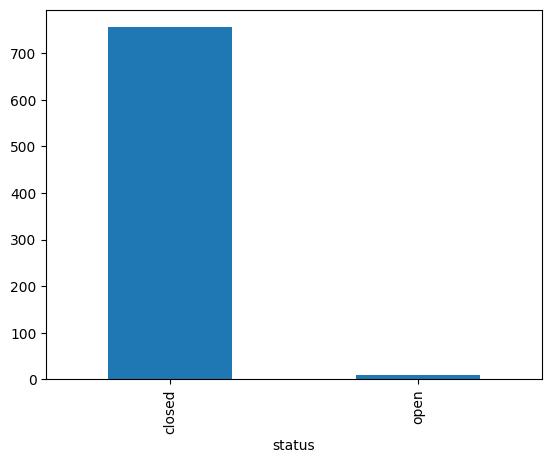

In [37]:
data['status'].value_counts().plot(kind='bar')

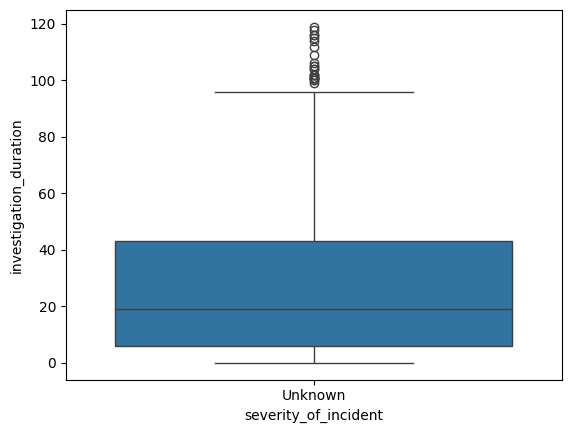

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='severity_of_incident', y='investigation_duration', data=data)
plt.show()

<Axes: xlabel='rootcause'>

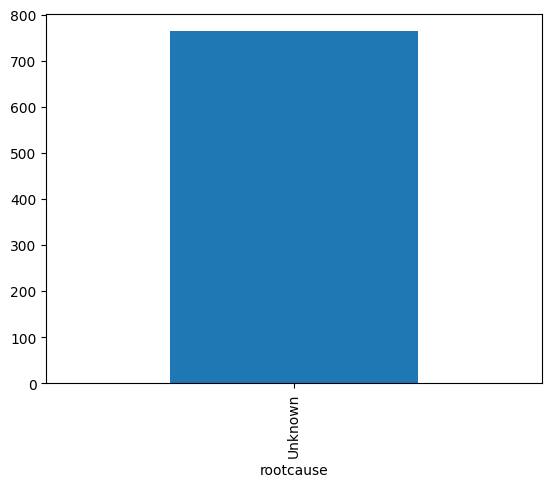

In [39]:
data['rootcause'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='country'>

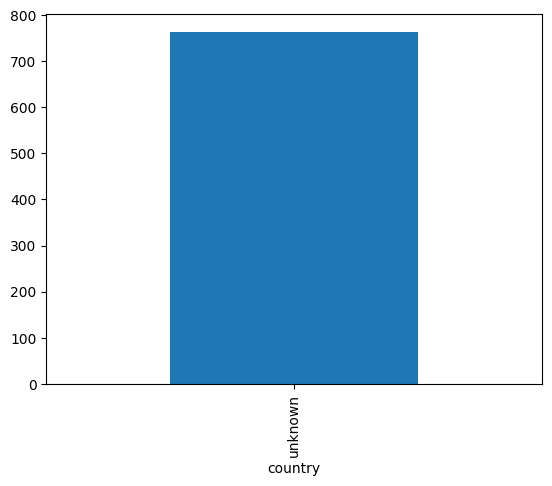

In [40]:
data['country'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='country'>

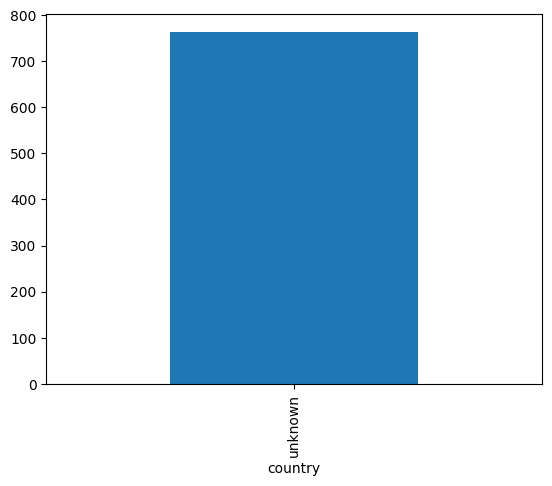

In [41]:
data['country'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='report_year'>

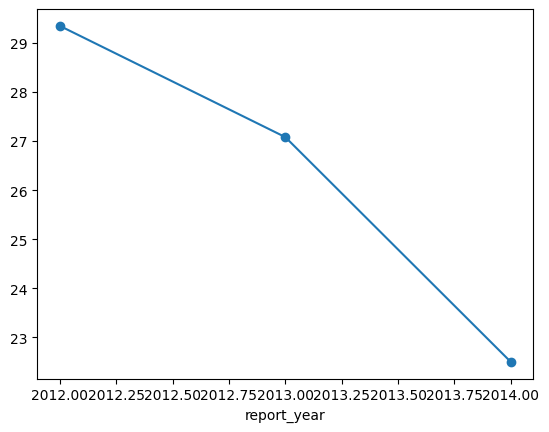

In [42]:
data.groupby('report_year')['investigation_duration'].mean().plot(marker='o')

<Axes: xlabel='related_department'>

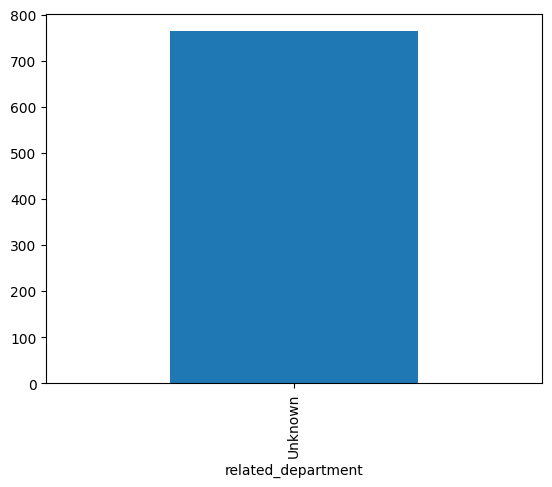

In [43]:
data['related_department'].value_counts().head(10).plot(kind='bar')

In [44]:
data.groupby(['country', 'ship_type']).size().sort_values(ascending=False).head(10)

country  ship_type   
unknown  tanker          332
         container       154
         bulk carrier    135
         oil tanker      124
         lpg carrier      18
         nan               1
dtype: int64

<Axes: xlabel='delay_days', ylabel='investigation_duration'>

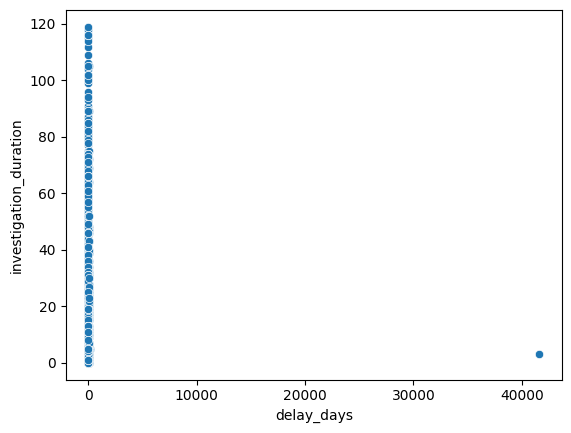

In [45]:
sns.scatterplot(x='delay_days', y='investigation_duration', data=data)